# Data Visualization

## Preparation
Import some modules, load an example dataset.


In [1]:
import pandas as pd
import seaborn as sns
%matplotlib inline

/Users/justin/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.2)
  from scipy.stats import gaussian_kde


In [2]:
!pip install seaborn

## Just to show you the Anscombe Figures

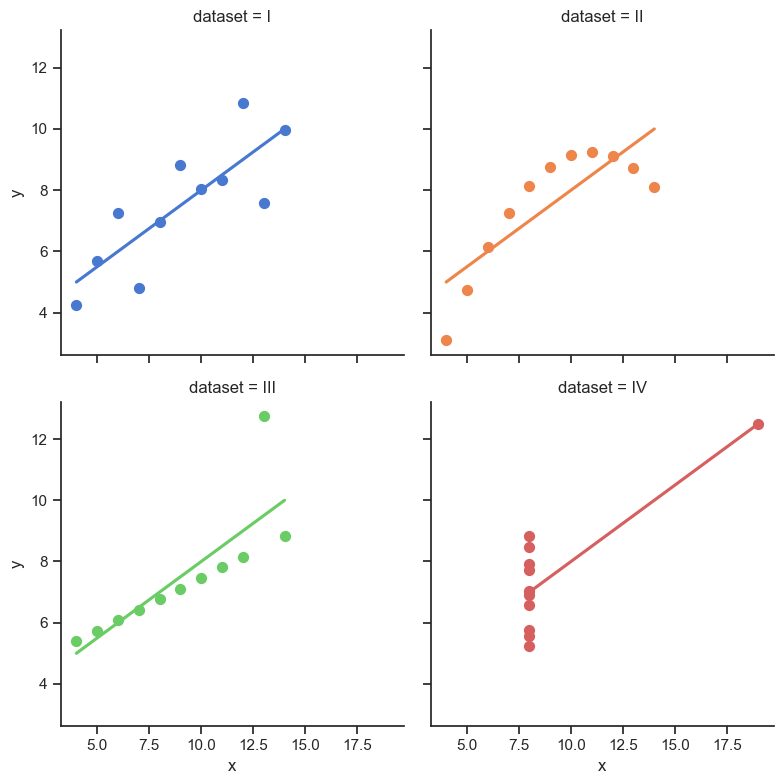

In [3]:
sns.set_theme(style="ticks")

# Load the example dataset for Anscombe's quartet
df = sns.load_dataset("anscombe")

# Show the results of a linear regression within each dataset
sns.lmplot(
    data=df, x="x", y="y", col="dataset", hue="dataset",
    col_wrap=2, palette="muted", ci=None,
    height=4, scatter_kws={"s": 50, "alpha": 1}
)

In [4]:
stats = (
    df.groupby("dataset")
      .apply(lambda g: pd.Series({
          "n": len(g),
          "x_mean": g["x"].mean(),
          "x_std": g["x"].std(),
          "y_mean": g["y"].mean(),
          "y_std": g["y"].std(),
          "pearson_r": g["x"].corr(g["y"])
      }))
      .round(3)
)

print(stats)

            n  x_mean  x_std  y_mean  y_std  pearson_r
dataset                                               
I        11.0     9.0  3.317   7.501  2.032      0.816
II       11.0     9.0  3.317   7.501  2.032      0.816
III      11.0     9.0  3.317   7.500  2.030      0.816
IV       11.0     9.0  3.317   7.501  2.031      0.817


## Grammar of Graphics:

A plot is a combination of layers that answer different questions:

- What data are we using?
- Which variables map to visual properties?
- What geometric marks should appear?
- Should the data be transformed statistically?
- How should values be scaled?
- Should we split into small multiple plots?
- What labels and theme make the plot readable?

### Data

In [5]:
import seaborn as sns

tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Aesthetics

Remember aesthetics map variables to visual properties

Common aesthetics:
- x
- y
- hue
- size
- style

Note: it can get very overwhelming very quick if you use too many "channels"

<Axes: xlabel='total_bill', ylabel='tip'>

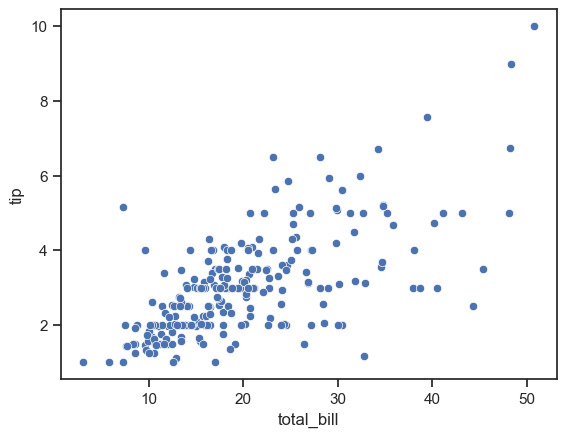

In [6]:
# Relationship between two variables
sns.scatterplot(
    data=tips,
    x="total_bill",
    y="tip"
)

<Axes: xlabel='total_bill', ylabel='tip'>

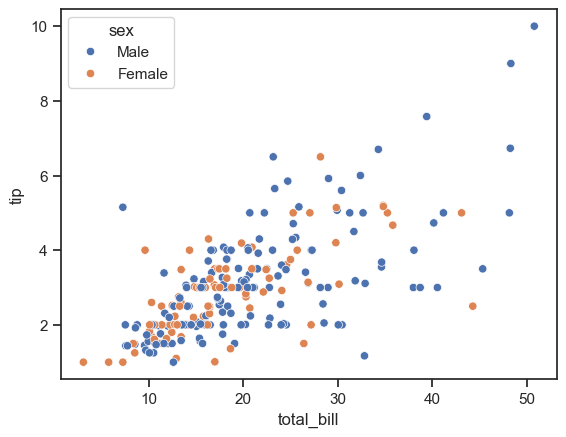

In [7]:
# Relationship between three variables is probably enough
sns.scatterplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="sex"
)

<Axes: xlabel='total_bill', ylabel='tip'>

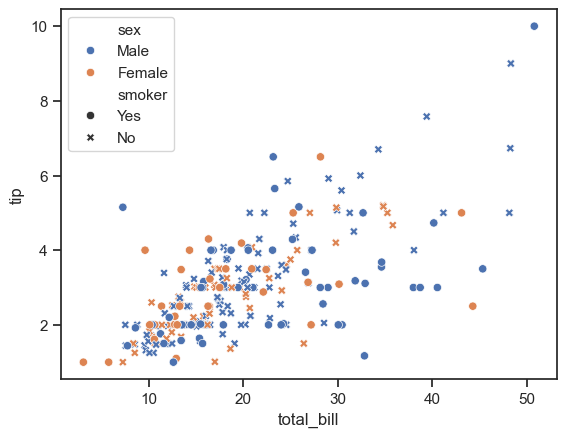

In [8]:
# Relationship between four variables is pushing it...
sns.scatterplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="sex",
    style="smoker"
)

<Axes: xlabel='total_bill', ylabel='tip'>

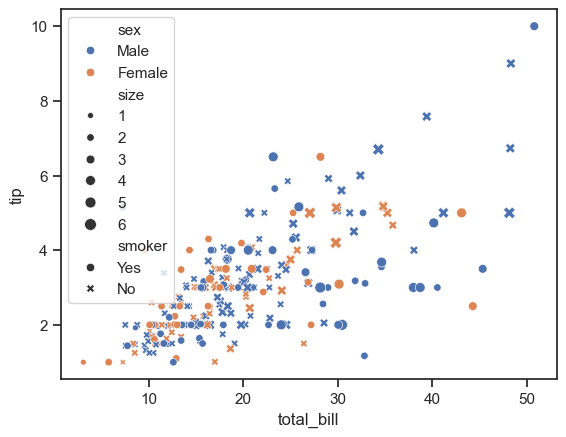

In [9]:
# Just don't do this
sns.scatterplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="sex",
    size="size",
    style="smoker"
)

### Geometry

Geometry is the kind of mark drawn on the chart

Examples of geometric choices:
- points
- lines
- bars
- boxes
- violins

<Axes: xlabel='total_bill', ylabel='tip'>

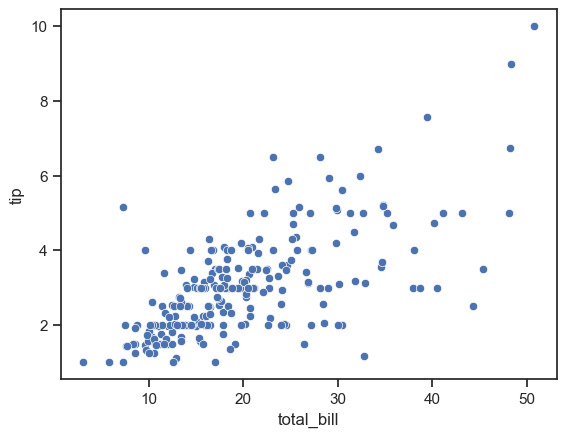

In [10]:
# Points
sns.scatterplot(data=tips, x="total_bill", y="tip")

<Axes: xlabel='day', ylabel='tip'>

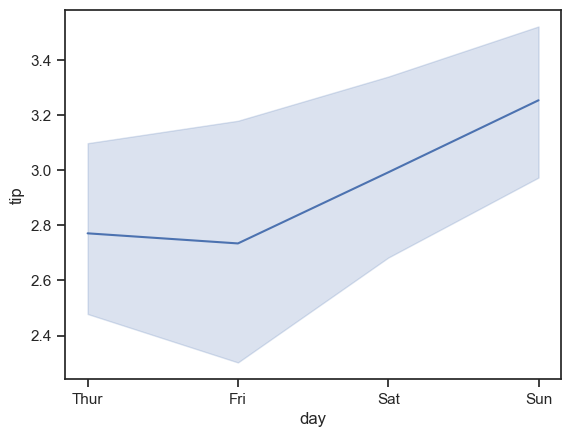

In [11]:
# Lines
sns.lineplot(data=tips, x="day", y="tip")

<Axes: xlabel='day', ylabel='total_bill'>

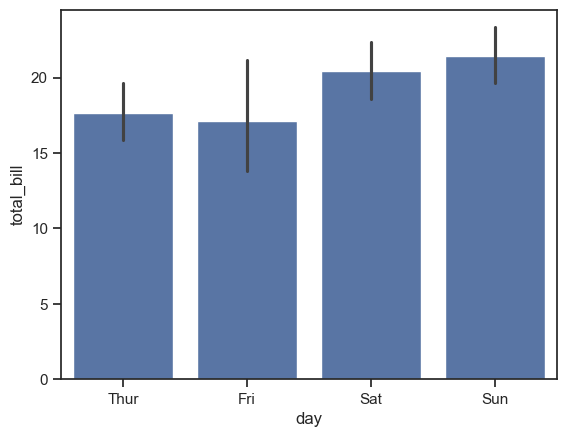

In [12]:
# Bars
sns.barplot(data=tips, x="day", y="total_bill")

<Axes: xlabel='day', ylabel='total_bill'>

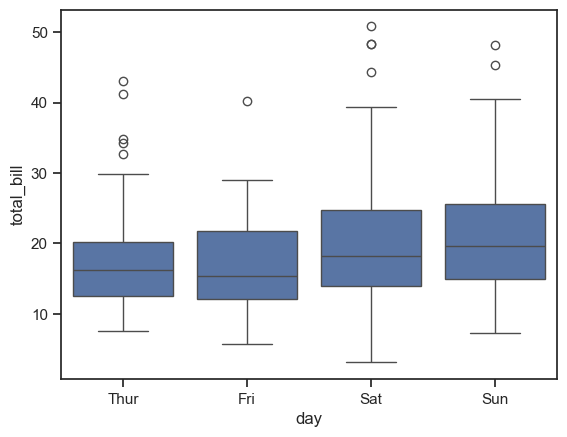

In [13]:
# Boxes
sns.boxplot(data=tips, x="day", y="total_bill")

<Axes: xlabel='day', ylabel='total_bill'>

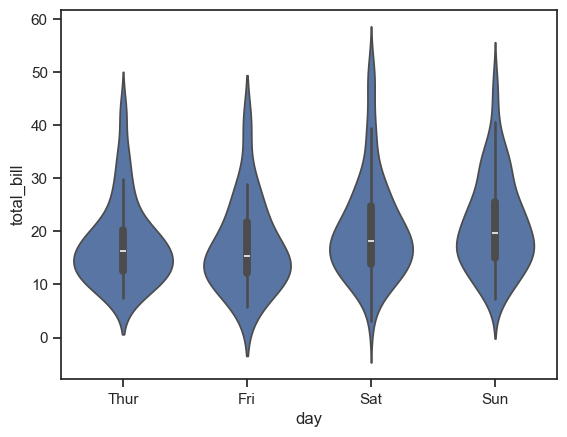

In [14]:
# Violins
sns.violinplot(data=tips, x="day", y="total_bill")

### Statistical Transformation

Note that sometimes seaborn shows raw data. Sometimes it shows a summary or model.

<Axes: xlabel='day', ylabel='tip'>

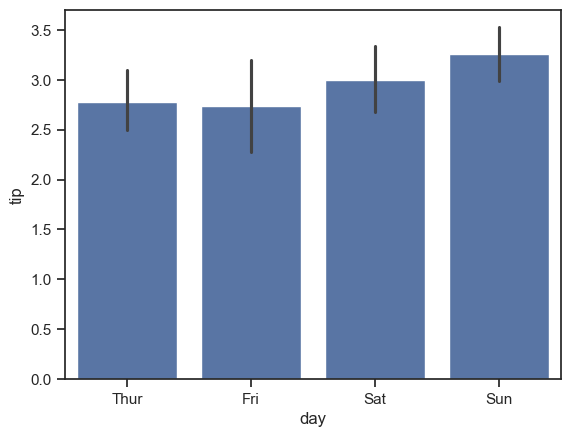

In [15]:
# barplot() does not simply draw each row
# It computes a summary statistic for each category

sns.barplot(data=tips, x="day", y="tip")

<Axes: xlabel='total_bill', ylabel='tip'>

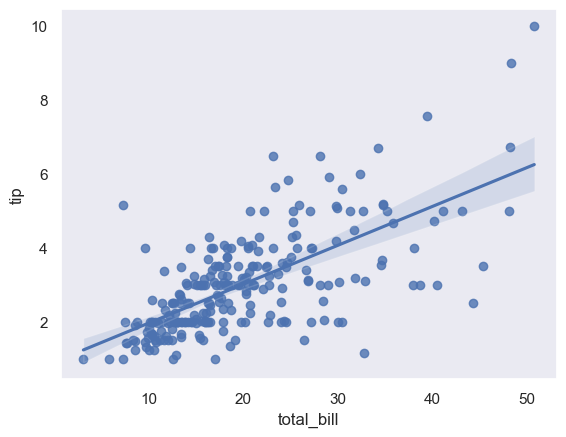

In [24]:
# lmplot() adds a regression model
# So the statistical layer is part of the visual

sns.regplot(data=tips, x="total_bill", y="tip")

### Scales

<Axes: xlabel='total_bill', ylabel='tip'>

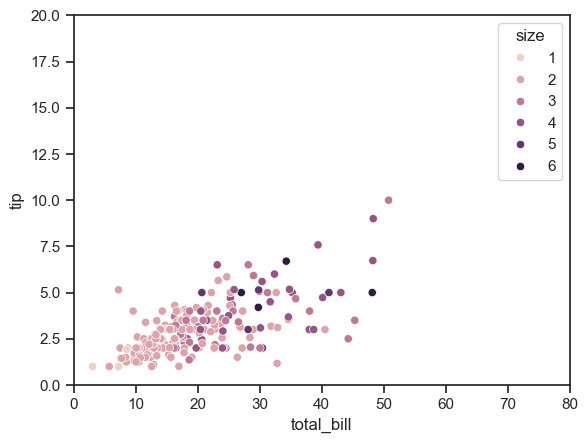

In [17]:
# Setting limits (how much should the axes show?)
ax = sns.scatterplot(data=tips, x="total_bill", y="tip", hue="size")
ax.set_xlim(0, 80)
ax.set_ylim(0, 20)
ax

[None]

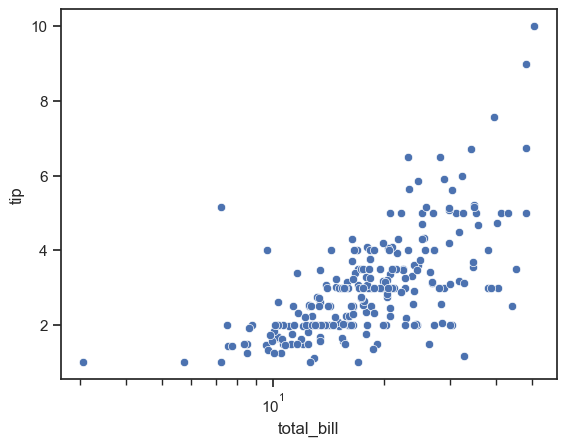

In [18]:
# Applying a log
ax = sns.scatterplot(data=tips, x="total_bill", y="tip")
ax.set(xscale="log")

### Facets

Faceting splits data into multiple small plots using subsets. 

This keeps the same mappings and geometry but compares groups in separate panels.

Faceting is powerful when one plot gets too crowded.

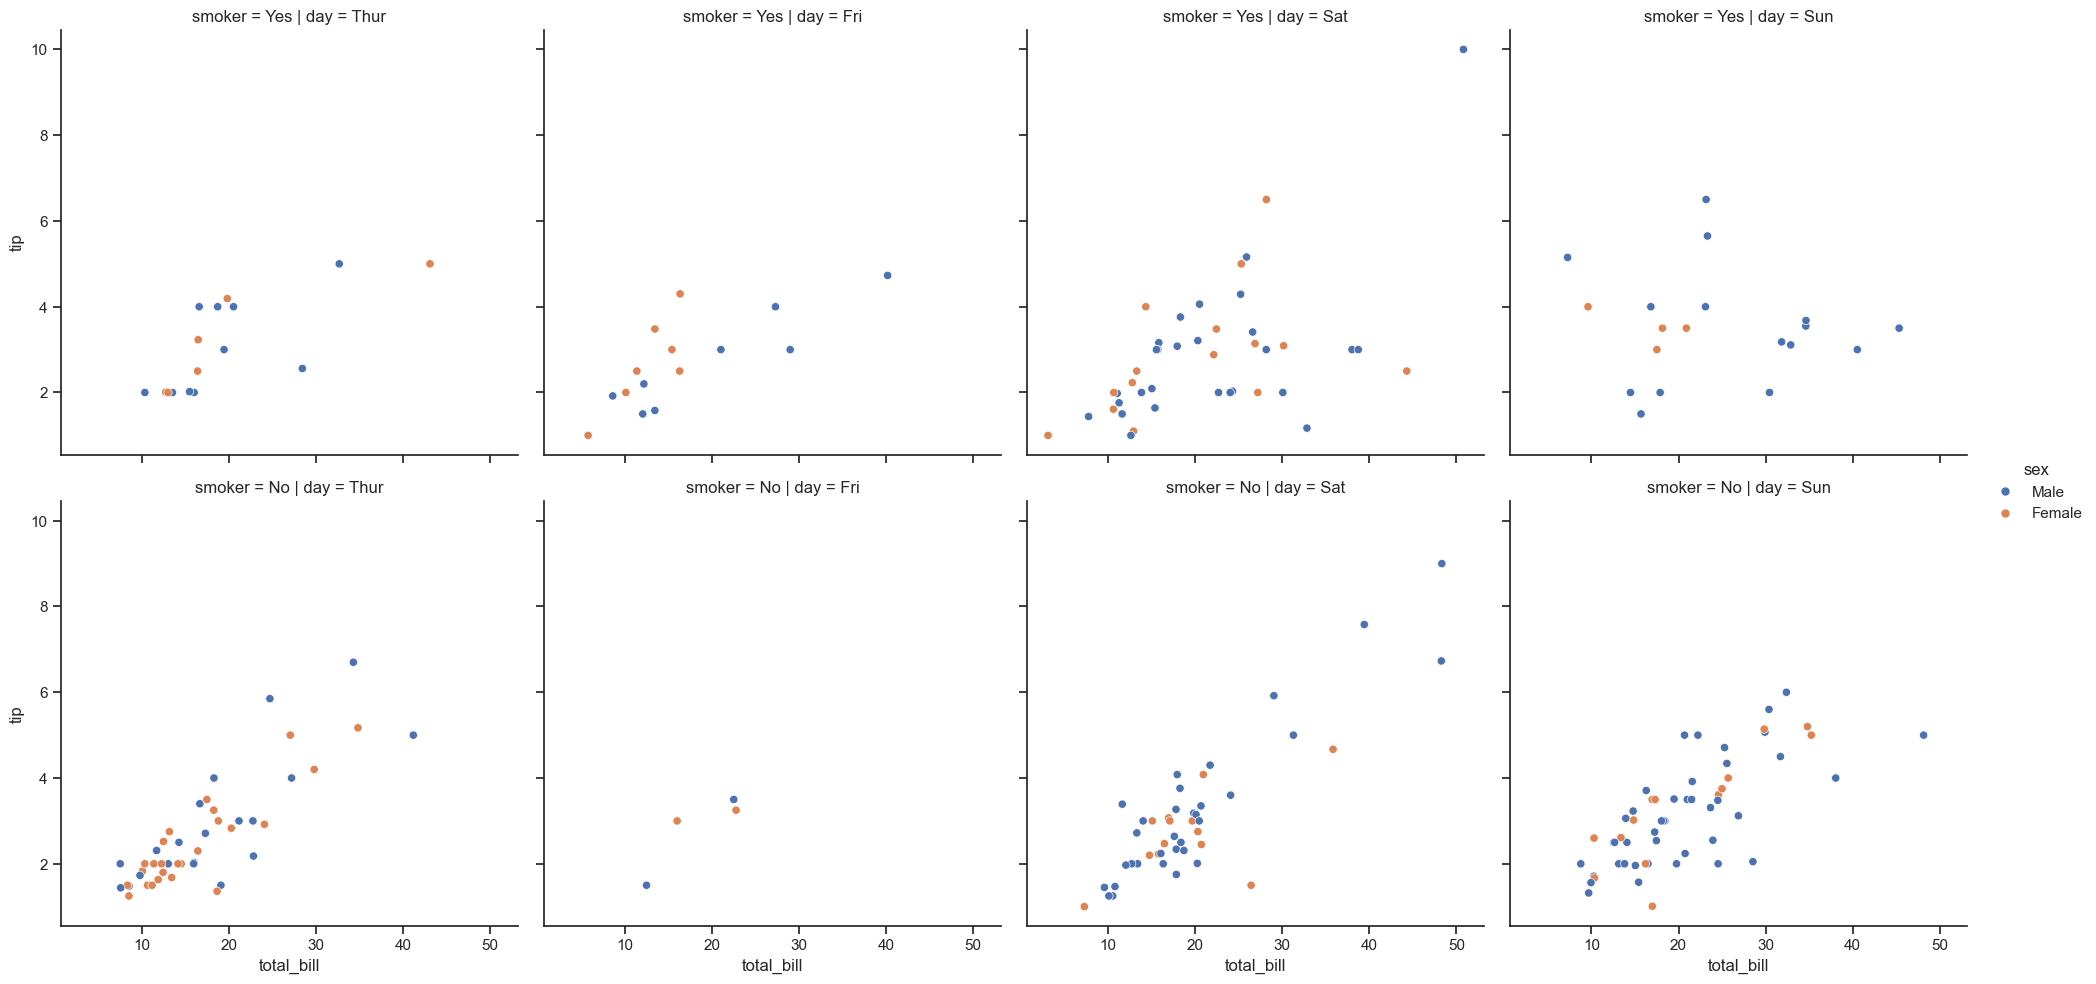

In [19]:
sns.relplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="sex",
    col="day",
    row="smoker"
)

### Labels

Labels explain the plot to the audience

<Axes: title={'center': 'Tips increase with total bill'}, xlabel='Total bill ($)', ylabel='Tip ($)'>

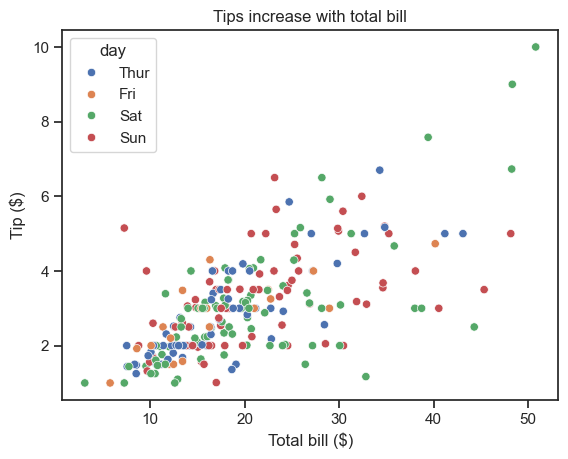

In [20]:
ax = sns.scatterplot(data=tips, x="total_bill", y="tip", hue="day")
ax.set(
    title="Tips increase with total bill",
    xlabel="Total bill ($)",
    ylabel="Tip ($)"
)
ax

### Theme

Themes control the overall look of the chart

<Axes: xlabel='total_bill', ylabel='tip'>

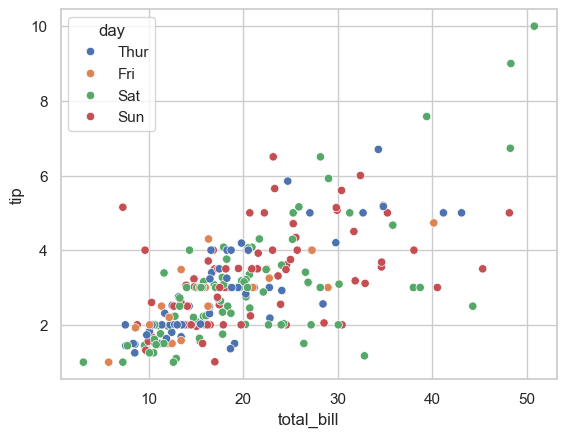

In [22]:
sns.set_theme(style="whitegrid")
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="day")

<Axes: xlabel='total_bill', ylabel='tip'>

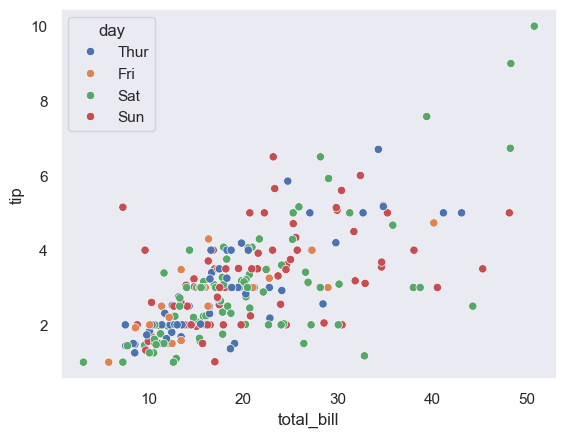

In [23]:
sns.set_theme(style="dark")
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="day")

In [45]:
sns.set_theme()

## Recap

### 1. Data
The dataset behind the plot.

- `data=`

## 2. Aesthetics
Map variables to visual properties.

Core:
- `x=`, `y=`, `hue=`, `size=`, `style=`

## 3. Geometry
Choose how data is drawn (the “mark”).

Functions:
- `sns.scatterplot()` — points  
- `sns.lineplot()` — lines  
- `sns.barplot()` — bars  
- `sns.boxplot()` — boxplots  
- `sns.violinplot()` — distributions  
- `sns.histplot()` — histograms  
- `sns.kdeplot()` — density  

`relplot` version:
- `sns.relplot(kind="scatter")`
- `sns.relplot(kind="line")`
- `sns.catplot(kind="bar")`
- `sns.displot(kind="hist")`

## 4. Statistical Transformation
Summarize or model the data.

Functions:
- `sns.barplot()` — mean + error bars  
- `sns.pointplot()` — summary points  
- `sns.countplot()` — counts  
- `sns.regplot()` — regression line  

## 5. Scales
Control how values map to axes/colors.

- `ax.set_xlim(...)`
- `ax.set_ylim(...)`
- `ax.set_xscale("log")`
- `ax.set_yscale("log")`

## 6. Facets
Split data into multiple plots.

Arguments:
- `row=`, `col=`

## 7. Annotation
Add titles and labels.

Axes-level:
- `ax.set_title(...)`
- `ax.set_xlabel(...)`
- `ax.set_ylabel(...)`

Figure-level:
- `ax.set_axis_labels(...)`
- `ax.set_titles(...)`

### Here's are some more plots...

<Axes: xlabel='day', ylabel='tip'>

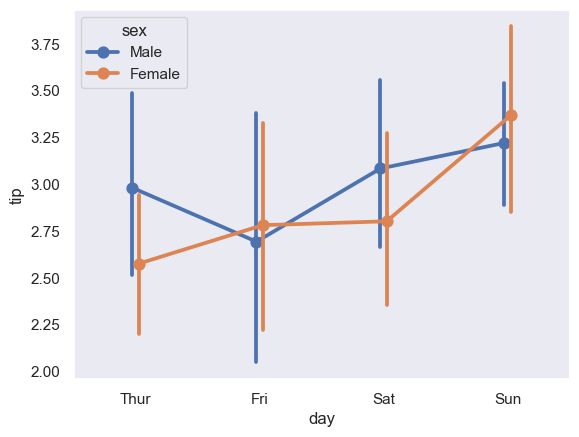

In [37]:
sns.pointplot(data=tips, x="day", y="tip", hue="sex", dodge=True)

<Axes: xlabel='day', ylabel='tip'>

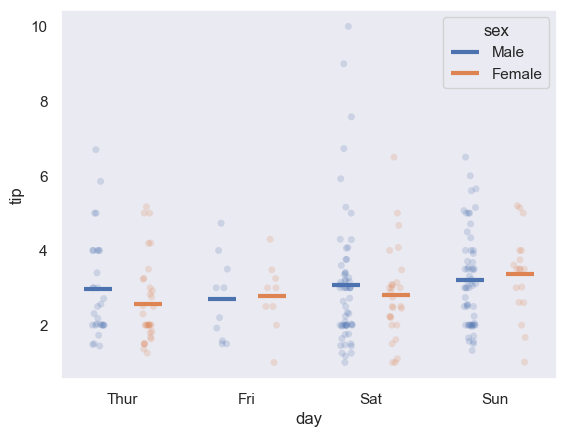

In [30]:
sns.stripplot(
    data=tips, x="day", y="tip", hue="sex",
    dodge=True, alpha=.2, legend=False,
)
sns.pointplot(
    data=tips, x="day", y="tip", hue="sex",
    dodge=.4, linestyle="none", errorbar=None,
    marker="_", markersize=20, markeredgewidth=3,
)

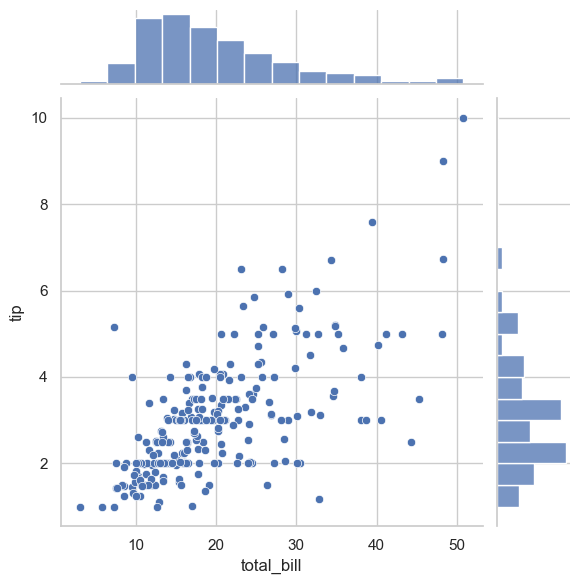

In [46]:
sns.set_theme(style="whitegrid")
sns.jointplot(data = tips, x = 'total_bill', y='tip', 
              kind="scatter")

# Bonus 

We do not cover this in this class, but you can also create interactive plots in Python:

In [48]:
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 5.0 MB/s eta 0:00:00a 0:00:01


In [50]:
pd.options.plotting.backend = "plotly"
fig = tips.plot(x= "total_bill", y='tip', kind='scatter', hover_data={"smoker":True})
fig.show()
fig.write_html("plotly-example.html")